# VGG16 Network

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vgg import VGG16

In [8]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive (this will ask for a quick authorization)
drive.mount('/content/drive')

# 2. Update this path to wherever your dataset folder is actually saved in your Drive
drive_dataset_path = '/content/drive/MyDrive/CV Lab4/dataset'

# 3. The local destination on Colab
local_dataset_path = '/content/dataset'

# 4. Copy it over
if not os.path.exists(local_dataset_path):
    print("Copying files to local runtime... Hang tight.")
    shutil.copytree(drive_dataset_path, local_dataset_path)
    print("Copy complete! Your dataset is now local.")
else:
    print("Dataset is already in the local runtime.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying files to local runtime... Hang tight.
Copy complete! Your dataset is now local.


## Setup

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Data Augmentation and Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Datasets
dataset_path = '/content/dataset'

# ImageFolder: loads images from a directory where each subdirectory is a class label
train_dataset = datasets.ImageFolder(root=f'{dataset_path}/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root=f'{dataset_path}/valid', transform=test_transforms)
test_dataset = datasets.ImageFolder(root=f'{dataset_path}/test', transform=test_transforms)

# Data Loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training VGG16 on the Pet Emotions Dataset

In [16]:
model = VGG16(number_of_classes=4).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10

print("Using device:", device)

train_losses = []
val_losses = []

# Training
for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # reset gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)
        loss = loss_function(outputs, labels)

        # backward pass and update weights
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Average loss for the epoch
    epoch_loss = running_train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Using device: cuda
Epoch [1/10] | Train Loss: 1.3883 | Val Loss: 1.3884
Epoch [2/10] | Train Loss: 1.3863 | Val Loss: 1.3942
Epoch [3/10] | Train Loss: 1.3867 | Val Loss: 1.3989
Epoch [4/10] | Train Loss: 1.3865 | Val Loss: 1.3919
Epoch [5/10] | Train Loss: 1.3867 | Val Loss: 1.3941
Epoch [6/10] | Train Loss: 1.3861 | Val Loss: 1.3398
Epoch [7/10] | Train Loss: 1.3854 | Val Loss: 1.3768
Epoch [8/10] | Train Loss: 1.3759 | Val Loss: 1.3911
Epoch [9/10] | Train Loss: 1.3660 | Val Loss: 1.3316
Epoch [10/10] | Train Loss: 1.3409 | Val Loss: 1.4444


Reference: https://arxiv.org/pdf/1409.1556

## Evaluation Phase

Accuracy: 0.3158
Mean Precision: 0.3533
Mean Recall: 0.3197
Mean F1-Score: 0.2956


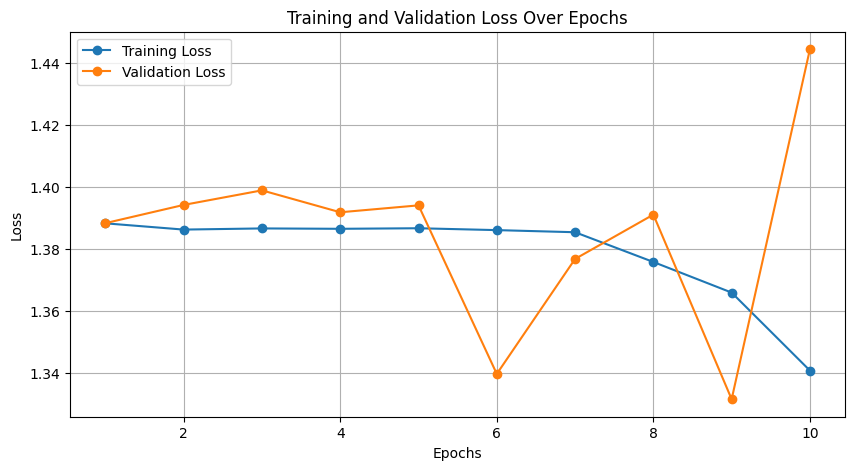

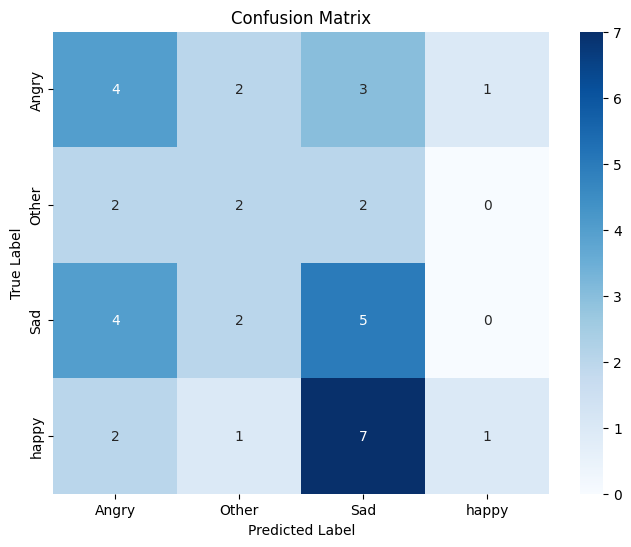

In [17]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions
        _, preds = torch.max(outputs, 1)

        # Move back to CPU and convert to numpy arrays for sklearn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
conf_matrix = confusion_matrix(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"Mean Precision: {precision:.4f}")
print(f"Mean Recall: {recall:.4f}")
print(f"Mean F1-Score: {f1:.4f}")


# Plotting the Loss Curves
plt.figure(figsize=(10, 5))
epochs_range = range(1, num_epochs + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
class_names = test_dataset.classes
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()